## Part 2: Solving a non-linear initial-value problem with the implicit Euler scheme

A municipality plans to build a large battery energy storage facility and is looking for a suitable location. The potential location is close (1 km) to a well that is used to abstract drinking water from an aquifer with a constant pumping rate $Q$. In the event of a fire or accident in the battery energy storage facility, contaminants could infiltrate into the subsurface.
Therefore, the municipality wants to assess the risk of contamination in case a leakage occurs.
One requirement is that the facility cannot be built in the groundwater protection zone, which is delineated by the area in which a water parcel takes less than 25 years to reach the well.

![](https://github.com/TUDelft-MUDE/source-files/raw/main/file/WS1.3/particle_tracking_schematic.svg)

Assuming radial flow towards the well in a uniform aquifer, the distance $r$ of a groundwater particle from the well is governed by

$$\frac{dr}{dt} = - \frac{Q}{2\pi r n b} = -\alpha\frac{1}{r}\,,$$

where $n$ is porosity, $b$ is the aquifer thickness, and $\alpha = \frac{Q}{2\pi nb}$.

To find out how long it takes for a particle starting at a distance $r_0$ to reach the well, you need to solve the ODE until the distance $r$ equals the well radius, $r_{\mathrm{well}}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
Q = 3000 # m³/d
b = 20 # m
n = 0.3

alpha = Q / (2 * np.pi * b * n)


r0 = 1000 # m
r_well = 0.2 # m


 > **Task 2.1**:

Formulate the implicit Euler scheme for the ODE.


For the ODE

$$\frac{dr}{dt} = -\frac{\alpha}{r},$$

the implicit Euler method evaluates the right-hand side at the new time level $t_{i+1}$. Therefore,

$$\frac{r_{i+1}-r_i}{\Delta t} = -\frac{\alpha}{r_{i+1}}.$$

Rearranging gives the implicit update equation

$$r_{i+1} = r_i - \Delta t\frac{\alpha}{r_{i+1}}.$$

Because $r_{i+1}$ appears on both sides of the equation, this is a nonlinear equation that must be solved iteratively for each time step.


For general nonlinear ODEs, the implicit Euler update cannot usually be solved directly. Instead, we use an iterative scheme – Newton-Raphson – to solve for $r_{i+1}$.[<sup>1</sup>](#fn1)

In the Newton-Raphson scheme, the expression for the new value, $r_{i+1}^{j+1}$, is given by:

$$r_{i+1}^{j+1} = r_{i+1}^{j} - \frac{q(r_{i+1}^{j})}{q^\prime(r_{i+1}^{j})}$$

Here $q$ is obtained by rearranging the implicit Euler expression so that one side of the equation is zero.

<sup id="fn1">1</sup> Note that the equation in this specific example is quadratic, and thus, could be solved directly, even though it is non-linear. For the sake of practicing, we ask you to use the Newton-Raphson method nevertheless.</span>




> **Task 2.2**:
> 
> Formulate an expression for $q$ by rearranging the equation for the implicit Euler scheme from task 2.1.


> **Task 2.3**:
> 
> Complete the code cell below to implement an implicit Euler scheme with Newton Raphson iterations for the particle-tracking ODE.

In [30]:
# Solve the IVP with an implicit Euler scheme, using the Newton-Raphson method

# Initialize variables
r_next = r0
r_previous = r0
t_previous = 0
dt = 50 # days

times = [t_previous]
r = [r0]

# Set parameters for the Newton-Raphson method and time iteration
tolerance = 1e-6
max_times = 1e4
max_iter = 50

# Loop over time
for iteration in range(int(max_times)):
    t_next = t_previous + dt
    times.append(t_next)
    iter_count = 0
    
    # Loop for Newton-Raphson iterations
    while iter_count < max_iter:
        # Define the function and its derivative
        q = r_next - r_previous + dt * alpha / r_next
        q_prime = 1 - dt * alpha / r_next**2

        # Update the guess using Newton-Raphson formula
        r_update = r_next - q / q_prime

        q_update = r_update - r_previous + dt * alpha / r_update
        q_prime_update = 1 - dt * alpha / r_update ** 2

        # Check for convergence
        if abs(r_update - r_next) < tolerance:
            break

        r_next = r_update
        iter_count += 1

    # Update the values for the next time step
    r_previous = r_next
    r_next = r_update
    r.append(r_next)
    t_previous = t_next

    # Stop the simulation when the particle reaches the well (r <= 0.2 m)
    if r_next <= r_well:
        break


> **Task 2.4**:
> 
> Run the code cell below to plot the numerical solution against the analytical solution

(0.0, 1000.0)

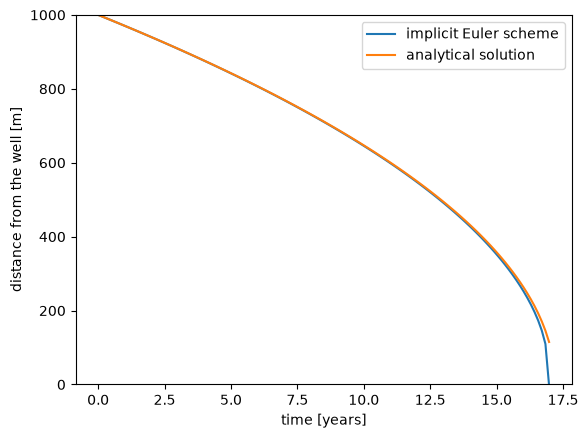

In [32]:
years = np.array(times) / 365.25
plt.plot(years, r, label="implicit Euler scheme")
plt.xlabel("time [years]")
plt.ylabel("distance from the well [m]")
r_analytical = np.sqrt(-2 * alpha * np.array(times) + r0**2)
plt.plot(years, r_analytical, label="analytical solution")
plt.legend()
plt.ylim(bottom=0, top =r0)

> **Task 2.5**:
> 
> Run the code cell below to compare the time it takes until the particle reaches the well between the numerical and analytical solution.

In [33]:
t_end_analytical = (r0**2 - r_well**2) / alpha
t_end_numerical = times[-1]

print("Time needed to reach the well (r=r_well):\n")
print(f"Analytical solution:\t{t_end_analytical / 365.25:.2f} years")
print(f"Numerical solution:\t{t_end_numerical / 365.25:.2f} years")

Time needed to reach the well (r=r_well):

Analytical solution:	34.40 years
Numerical solution:	16.97 years


> **Task 2.6**:
> 
> Based on this estimate, would you recommend approving the proposed location? Explain your reasoning.

> By Ronald Brinkgreve, Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).